In [2]:
import rasterio
import xarray as xr
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt


In [63]:
# import raster files
msa_file = '../gis/msa/msaUS_mland_aea1_M1.shp'
msa_ds=gpd.read_file(msa_file)

### Pixel count for each range, original and downscaled NEE

Original NEE is all in range (-10, 10) 
while downscaled NEE has extreme values and more pixels closer to 0

In [142]:
# get raster value count by range for original NEE

year_month = '200101'
downscaled_nee_file_path = f'../gis/output/downscaledNEE/downscaledNEE_US_{year_month}.tif'

variable = 'NEE'
original_nee_file_path = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year_month[:4]}.nc'

ds = xr.open_dataset(original_nee_file_path)
original_nee = ds[variable][int(year_month[4:]) - 1].values
valid_values = original_nee[~np.isnan(original_nee)]

counts = {}
bounds = [(-10000000, -100), (-100, -10), (-10, -1), (-1, 0), (0, 0.00001), (0.00001, 1), (1, 10), (10, 100), (100, 10000000)] 
for lower, upper in bounds:
    counts[(lower, upper)] = np.sum((valid_values >= lower) & (valid_values < upper))
counts

{(-10000000, -100): np.int64(0),
 (-100, -10): np.int64(0),
 (-10, -1): np.int64(264058),
 (-1, 0): np.int64(446485),
 (0, 1e-05): np.int64(16),
 (1e-05, 1): np.int64(1044471),
 (1, 10): np.int64(2215),
 (10, 100): np.int64(0),
 (100, 10000000): np.int64(0)}

In [143]:
# get raster value count by range for downscaled NEE
with rasterio.open(downscaled_nee_file_path) as src:
    raster_data = src.read(1)  # Read the first band
    raster_data = np.where(raster_data == src.nodata, np.nan, raster_data)  # Replace nodata values with NaN

valid_values = raster_data[~np.isnan(raster_data)]
counts = {}
bounds = [(-10000000, -100), (-100, -10), (-10, -1), (-1, 0), (0, 0.00001), (0.00001, 1), (1, 10), (10, 100), (100, 10000000)] 
for lower, upper in bounds:
    counts[(lower, upper)] = np.sum((valid_values >= lower) & (valid_values < upper))

counts

{(-10000000, -100): np.int64(275),
 (-100, -10): np.int64(2334),
 (-10, -1): np.int64(91136),
 (-1, 0): np.int64(8559144),
 (0, 1e-05): np.int64(9195694),
 (1e-05, 1): np.int64(19534415),
 (1, 10): np.int64(1101530),
 (10, 100): np.int64(20103),
 (100, 10000000): np.int64(614)}

### Histogram of pixel count / pixel number, for downscaled and original NEE comparison

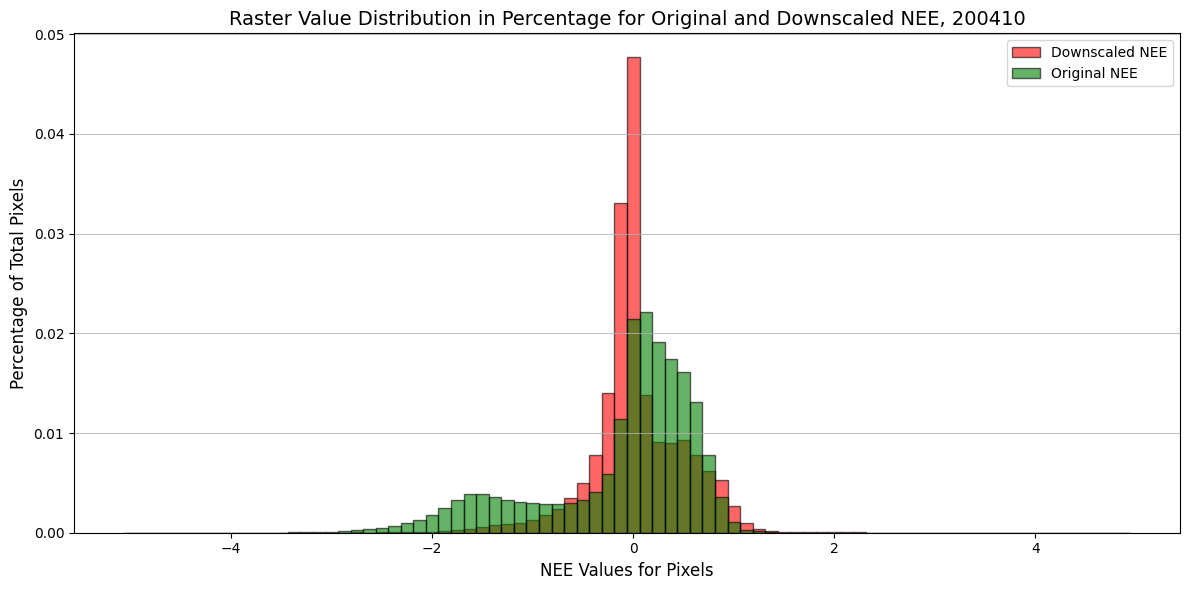

In [175]:
# Plot the pixel count / pixel number histograms
bins=80
year_month = '200410'
title=f"Raster Value Distribution in Percentage for Original and Downscaled NEE, {year_month}"
x_min = -5
x_max = 5


downscaled_nee_file = f'../gis/output/downscaledNEE/downscaledNEE_US_{year_month}.tif'
original_nee_file_path = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year_month[:4]}.nc'

with rasterio.open(downscaled_nee_file) as src:
    downscaled_nee = src.read(1)  # Read the first band
    downscaled_nee = np.where(downscaled_nee == src.nodata, np.nan, downscaled_nee)  # Replace nodata values with NaN

variable = 'NEE'
ds = xr.open_dataset(original_nee_file_path)
original_nee = ds[variable][int(year_month[4:]) - 1].values  # Extract data for the specified month

valid_downscaled = downscaled_nee[(~np.isnan(downscaled_nee))]
valid_original = original_nee[(~np.isnan(original_nee))]

# Calculate total number of pixels in the raster
total_pixels_downscaled = downscaled_nee.size  # Total pixels (rows * cols)
total_pixels_original = original_nee.size

# Compute histograms
hist_downscaled, bin_edges = np.histogram(valid_downscaled, bins=bins, range=(x_min, x_max))
hist_original, _ = np.histogram(valid_original, bins=bins, range=(x_min, x_max))

# Convert counts to percentages
hist_downscaled_percentage = hist_downscaled / total_pixels_downscaled
hist_original_percentage = hist_original / total_pixels_original

# Plot histogram with correct percentages
plt.figure(figsize=(12, 6))
plt.bar(bin_edges[:-1], hist_downscaled_percentage, width=np.diff(bin_edges), color='red', alpha=0.6, edgecolor='black', label='Downscaled NEE')
plt.bar(bin_edges[:-1], hist_original_percentage, width=np.diff(bin_edges), color='green', alpha=0.6, edgecolor='black', label='Original NEE')

plt.title(title, fontsize=14)
plt.xlabel('NEE Values for Pixels', fontsize=12)
plt.ylabel('Percentage of Total Pixels', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


### NEE mean for each MSA


#### calculate msa nee mean for downscaled

In [256]:
import rasterio
import geopandas as gpd
import numpy as np
import xarray as xr
import pandas as pd
from rasterio.mask import mask

# Define file paths
year_month = '200101'
downscaled_nee_file_path = f'../gis/output/downscaledNEE/downscaledNEE_US_{year_month}.tif'
msa_file = '../gis/msa/msaUS_mland_aea1_M1.shp'


# Load the MSA shapefile
msa_gdf = gpd.read_file(msa_file)

# Read the downscaled NEE raster
with rasterio.open(downscaled_nee_file_path) as src:
    downscaled_nee = src.read(1)
    downscaled_nee = np.where(downscaled_nee == src.nodata, np.nan, downscaled_nee)
    raster_meta = src.meta.copy()

# Ensure CRS match between raster and shapefile
msa_gdf = msa_gdf.to_crs(raster_meta['crs'])

# Function to compute mean NEE for each MSA
def calculate_msa_mean(raster_file, msa_gdf):
    mean_values = []
    for _, row in msa_gdf.iterrows():
        msa_geometry = [row['geometry']]
        with rasterio.open(raster_file) as src:
            out_image, _ = mask(src, msa_geometry, crop=True, nodata=np.nan)
            out_image = out_image[0]
        
        # Compute mean ignoring NaNs
        mean_value = np.nanmean(out_image) if np.any(~np.isnan(out_image)) else np.nan
        mean_values.append(mean_value)
    return mean_values

# Compute mean NEE for downscaled data
nee_downscaled_msa_mean = calculate_msa_mean(downscaled_nee_file_path, msa_gdf)


#### calculate nee mean for original NEE

In [257]:
import rasterstats as rstats

# get NEE crs which is equal to GPP crs (EPSG:4326)
gpp_file = f'../gis/GPP_monthly_mean/gpp_200101.tif'
with rasterio.open(gpp_file) as gpp_dstrd:
    gpp_crs = gpp_dstrd.crs
nee_crs = gpp_crs

# get original NEE transform
minx, miny, maxx, maxy = -180.0, -90.0, 180.0, 90.0
nee_orig_resolution_x = 1/12
nee_orig_resolution_y = 1/12
nee_orig_transform = rasterio.transform.from_origin(minx, maxy, nee_orig_resolution_x, nee_orig_resolution_y)
nee_orig_transform

# get original NEE value for specific year month
original_nee_file_path = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year_month[:4]}.nc'
variable = 'NEE'
ds = xr.open_dataset(original_nee_file_path)
original_nee = ds[variable][int(year_month[4:]) - 1].values  # Extract data for the specified month

# make sure msa and nee are in same crs
msa_gdf_crsaea = gpd.read_file(msa_file)
msa_gdf_crs4326 = msa_gdf_crsaea.to_crs(nee_crs)
nee_orig_msa_mean = []

# calculate mean original NEE for each MSA
for index, row in msa_gdf_crs4326.iterrows():
    shape_info = row['geometry']
    name = row['NAMELSAD']
    # go through all geometries and compute zonal statistics
    res = rstats.zonal_stats(shape_info, original_nee, affine=nee_orig_transform, stats="mean")
    mean = res[0]['mean']
    # print(name, mean)
    nee_orig_msa_mean.append(mean)

#### compare the original and downscaled nee mean for each msa

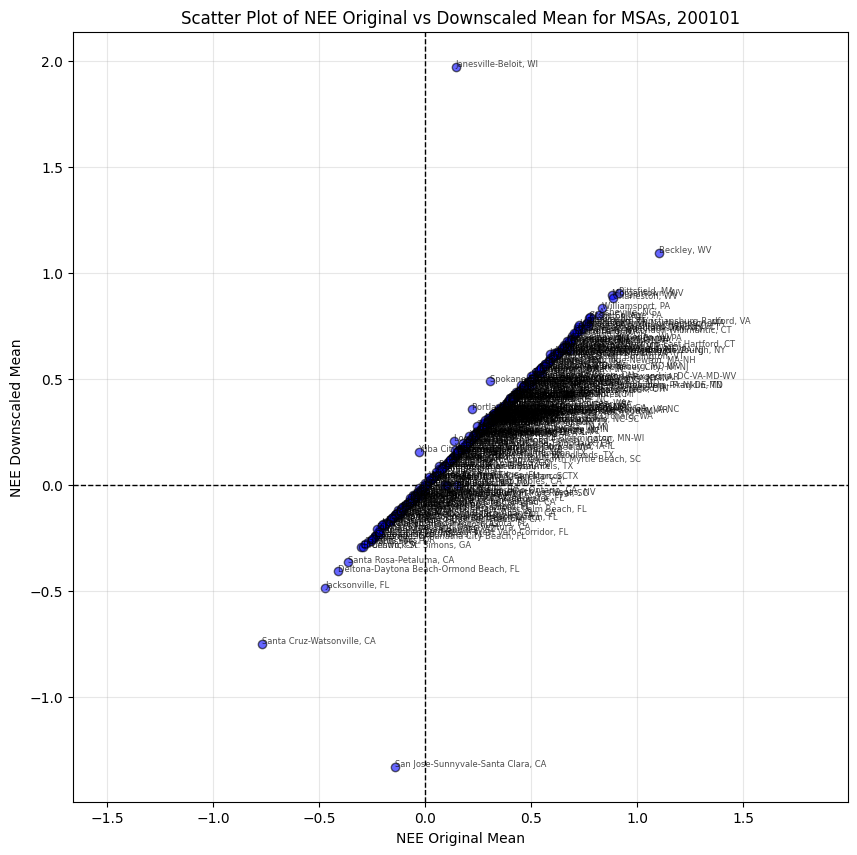

In [258]:
# add the mean values to the msa dataframe
msa_gdf['nee_downscaled_msa_mean'] = nee_downscaled_msa_mean
msa_gdf['nee_orig_msa_mean'] = nee_orig_msa_mean
msa_mean_compare = msa_gdf[['NAMELSAD', 'nee_downscaled_msa_mean', 'nee_orig_msa_mean']]
# msa_mean_compare.to_csv(f'msa_mean_compare{year_month}.csv', index=False)

import matplotlib.pyplot as plt
# Prepare data for scatter plot
x_values = msa_mean_compare['nee_orig_msa_mean']
y_values = msa_mean_compare['nee_downscaled_msa_mean']
labels = msa_mean_compare['NAMELSAD'].str[:-10]  # Remove the last 10 characters for labeling

# Create scatter plot
plt.figure(figsize=(10, 10))
plt.scatter(x_values, y_values, color='blue', alpha=0.6, edgecolors='black')

# Annotate points with MSA names
for i, label in enumerate(labels):
    plt.annotate(label, (x_values[i], y_values[i]), fontsize=6, alpha=0.7)
    
plt.axis('equal')

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)


# Add labels and title
plt.xlabel('NEE Original Mean')
plt.ylabel('NEE Downscaled Mean')
plt.title(f'Scatter Plot of NEE Original vs Downscaled Mean for MSAs, {year_month}')

# Show grid
plt.grid(alpha=0.3)
plt.show()


### NEE/GPP ratio distribution

#### Pixel Level

C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_21984\873269846.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


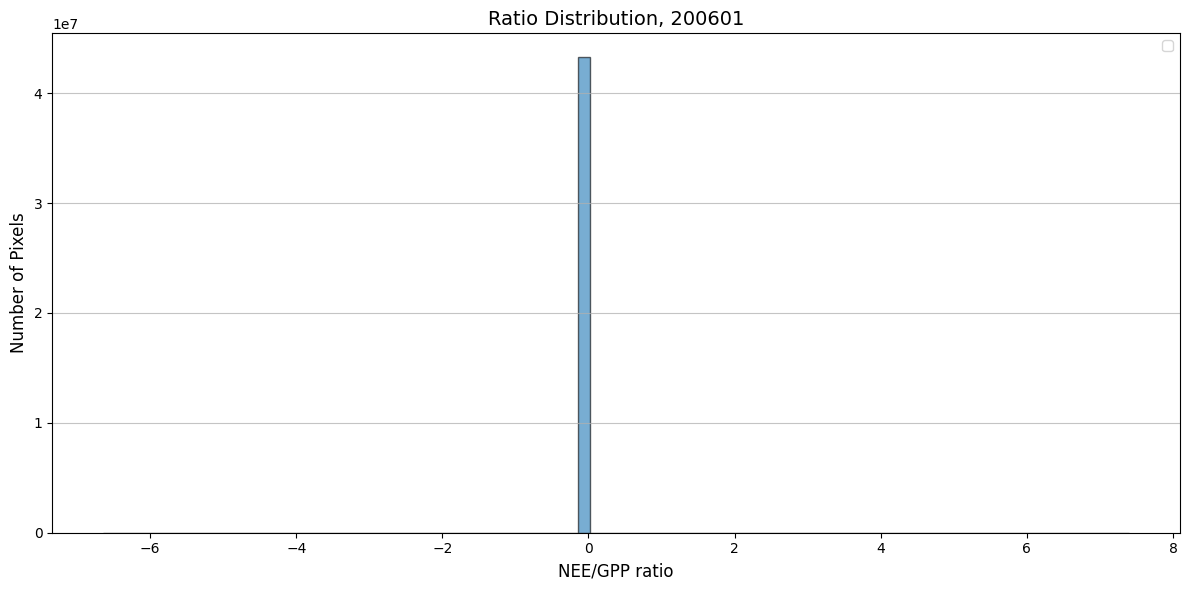

In [10]:
# Plot the pixel count / pixel number histograms
bins=80

year_month = '200601'
title=f"Ratio Distribution, {year_month}"
year = year_month[:4]
month = year_month[4:]
downscaled_ratio_file = f'../gis/output/downscaleRatio/ratio_us_{year}_{month}.tif'


with rasterio.open(downscaled_ratio_file) as src:
    ratio = src.read(1)  # Read the first band
    ratio_profile = src.profile
    ratio = np.where(ratio == src.nodata, np.nan, ratio)  # Replace nodata values with NaN

valid_ratio = ratio[(~np.isnan(ratio))]

# Plot histogram with correct percentages
plt.figure(figsize=(12, 6))

x_min = -1
x_max = 2
plt.hist(valid_ratio, bins=bins, alpha=0.6, edgecolor='black')
plt.title(title, fontsize=14)
plt.xlabel('NEE/GPP ratio', fontsize=12)
plt.ylabel('Number of Pixels', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_21984\2452623407.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


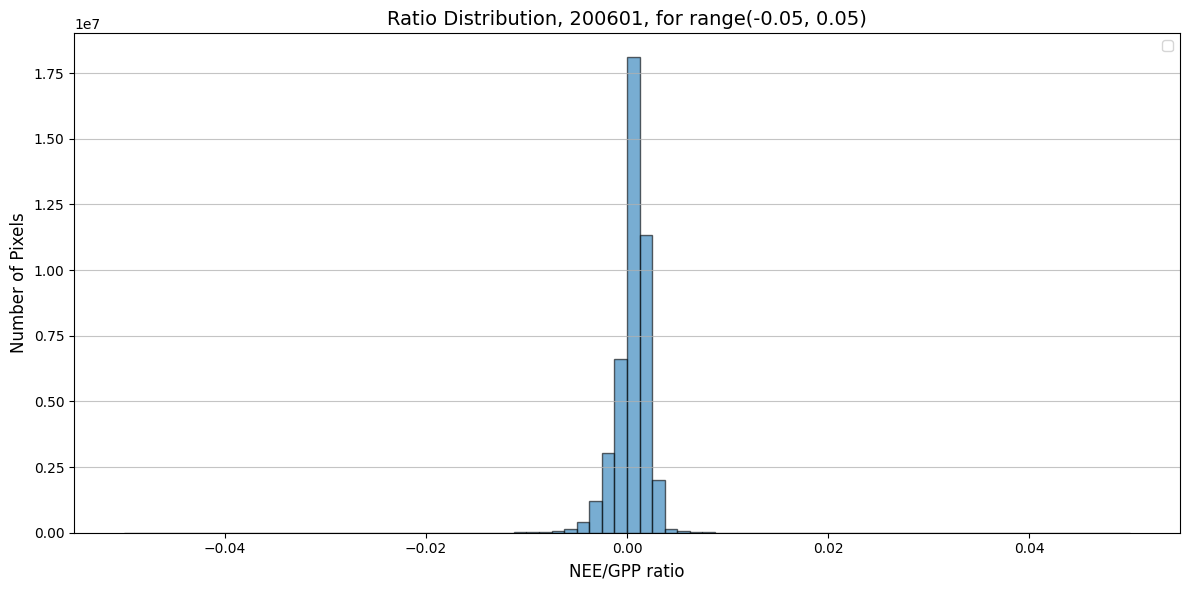

In [4]:
x_min = -0.05
x_max = 0.05
plt.figure(figsize=(12, 6))
plt.hist(valid_ratio, bins=bins, range=(x_min, x_max), alpha=0.6, edgecolor='black')

plt.title(title + f', for range({x_min}, {x_max})', fontsize=14)
plt.xlabel('NEE/GPP ratio', fontsize=12)
plt.ylabel('Number of Pixels', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

#### Plot the area where there is extreme ratio

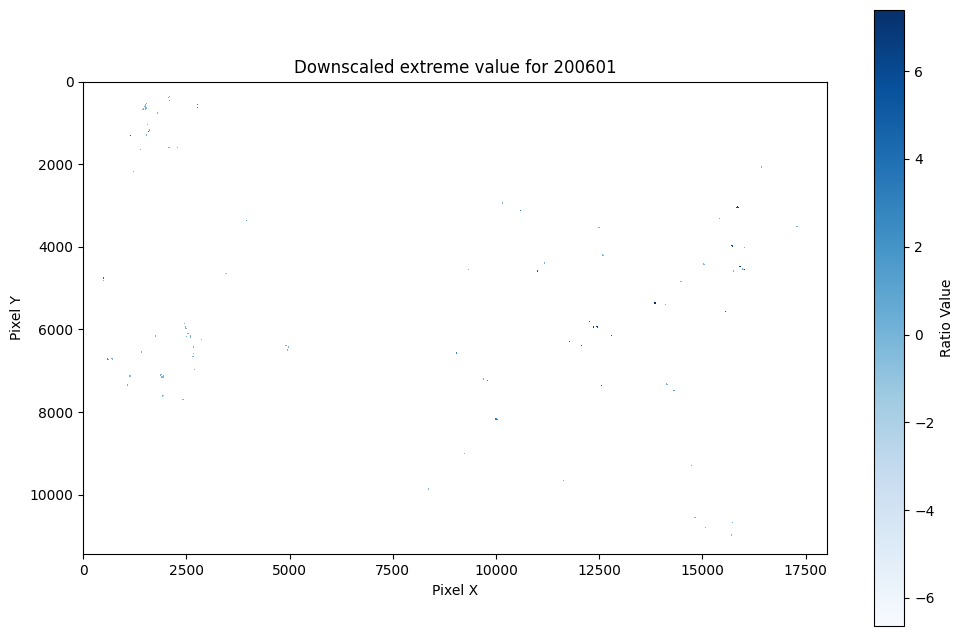

In [11]:
threshold = 0.01
condition = (ratio < -1 * threshold) | (ratio > threshold)
masked_ratio = np.where(condition, ratio, np.nan)

plt.figure(figsize=(12, 8))

plt.imshow(masked_ratio, cmap='Blues', interpolation='nearest')
plt.colorbar(label='Ratio Value')
plt.title(f'Downscaled extreme value for {year_month}')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')

plt.show()

In [12]:
# Create a new raster with extreme values (1 for extreme, 0 for others)
extreme_raster = np.where(condition, 1, 0).astype(np.uint8)

# Save the extreme values raster
ratio_profile.update(dtype=rasterio.uint8, count=1, nodata=0)  # Update profile for the new raster

extreme_ratio_mask_file = f'../gis/output/downscaleRatio/extreme_ratios_mask_{year_month}_{str(threshold)}.tif'
with rasterio.open(extreme_ratio_mask_file, 'w', **ratio_profile) as dst:
    dst.write(extreme_raster, 1)
print(f"Extreme values raster saved to {extreme_ratio_mask_file}")

Extreme values raster saved to ../gis/output/downscaleRatio/extreme_ratios_mask_200601_0.01.tif


#### Mean ratio for each MSA

<Figure size 2000x1200 with 0 Axes>

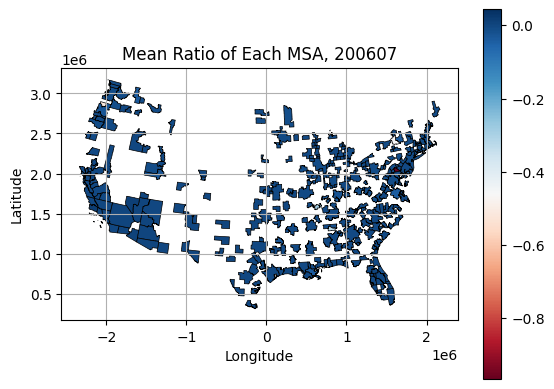

MSAswith lowest mean NEE/GPP ratio, 200607:
                       MSA_Name  Mean_Ratio
191            York-Hanover, PA   -0.966088
295          Longview-Kelso, WA   -0.509187
344                Syracuse, NY   -0.464338
200                 Decatur, AL   -0.324099
281              Paducah, KY-IL   -0.288311
268    New Orleans-Metairie, LA   -0.041064
58                 Richmond, VA   -0.040422
338  Spokane-Spokane Valley, WA   -0.038295
38               Utica-Rome, NY   -0.037961
235           Elizabethtown, KY   -0.034215
MSAswith highest mean NEE/GPP ratio, 200607:
                                    MSA_Name  Mean_Ratio
326                              Vallejo, CA    0.043383
61             Santa Maria-Santa Barbara, CA    0.018627
226  Las Vegas-Henderson-North Las Vegas, NV    0.012670
68                                  Yuma, AZ    0.005020
232     Riverside-San Bernardino-Ontario, CA    0.003668
251                               Odessa, TX    0.003405
170                         

In [244]:
import rasterio
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from rasterio.mask import mask

year_month = '200607'
year = year_month[:4]
month = year_month[4:]
downscaled_ratio_file = f'../gis/output/downscaleRatio/ratio_us_{year}_{month}.tif'
msa_file = '../gis/msa/msaUS_mland_aea1_M1.shp'

# Load the MSA shapefile
msa_gdf = gpd.read_file(msa_file)

# Open the raster file
with rasterio.open(downscaled_ratio_file) as src:
    ratio = src.read(1)  # Read the first band
    ratio = np.where(ratio == src.nodata, np.nan, ratio)  # Replace nodata values with NaN
    raster_meta = src.meta.copy()

# Ensure CRS match between shapefile and raster
msa_gdf = msa_gdf.to_crs(raster_meta['crs'])

# Function to compute mean for each MSA and store it in the GeoDataFrame
mean_ratios = []

for index, row in msa_gdf.iterrows():
    msa_geometry = [row['geometry']]  # Extract geometry
    with rasterio.open(downscaled_ratio_file) as src:
        out_image, out_transform = mask(src, msa_geometry, crop=True, nodata=np.nan)
        out_image = out_image[0]  # Extract the first band

    # Remove NaN values and calculate the mean
    valid_pixels = out_image[~np.isnan(out_image)]
    mean_ratio = np.mean(valid_pixels) if valid_pixels.size > 0 else np.nan
    mean_ratios.append(mean_ratio)

# Add mean ratio values to the GeoDataFrame
msa_gdf['mean_ratio'] = mean_ratios

# Plot the map with the mean ratios
plt.figure(figsize=(20, 12))
msa_gdf.plot(column='mean_ratio', cmap='RdBu', legend=True, edgecolor='black', linewidth=0.5)
plt.title(f'Mean Ratio of Each MSA, {year_month}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

import pandas as pd
msa_stats_df = pd.DataFrame({
    'MSA_Name': msa_gdf['NAME'],  # Replace 'NAME' with the actual column for MSA names
    'Mean_Ratio': msa_gdf['mean_ratio']
})
msa_stats_df.describe()
print(f'MSAswith lowest mean NEE/GPP ratio, {year_month}:')
print(msa_stats_df.sort_values(by='Mean_Ratio', ascending=True).head(10))
print(f'MSAswith highest mean NEE/GPP ratio, {year_month}:')
print(msa_stats_df.sort_values(by='Mean_Ratio', ascending=False).head(10))

### previous

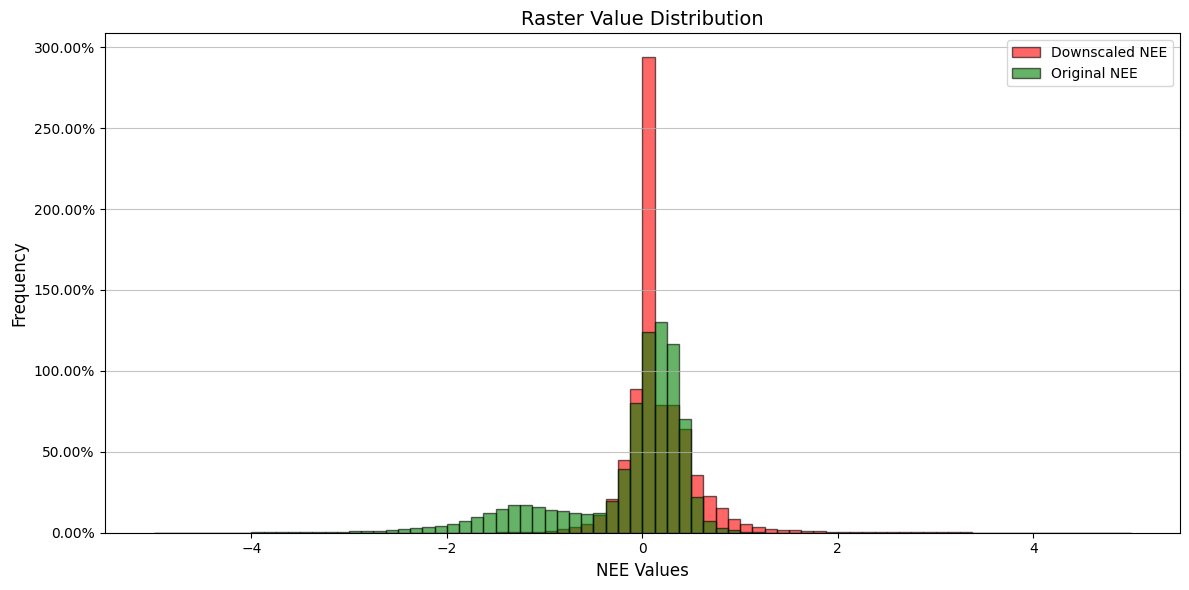

In [83]:

bins=80
title="Raster Value Distribution"
year_month = '200101'

downscaled_nee_file = f'../gis/output/downscaledNEE/downscaledNEE_US_{year_month}.tif'
original_nee_file_path = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year_month[:4]}.nc'

with rasterio.open(downscaled_nee_file) as src:
    downscaled_nee = src.read(1)  # Read the first band
    downscaled_nee = np.where(raster_data == src.nodata, np.nan, raster_data)  # Replace nodata values with NaN

variable = 'NEE'
ds = xr.open_dataset(original_nee_file_path)
original_nee = ds[variable][int(year_month[4:]) - 1].values  # Extract data for the specified month

valid_downscaled = downscaled_nee[(~np.isnan(downscaled_nee))]
valid_original = original_nee[(~np.isnan(original_nee))]

x_min = -5
x_max = 5

# Plot the pixel count histograms
plt.figure(figsize=(12, 6))
plt.hist(valid_downscaled, bins=bins, range=(x_min, x_max), density=True, color='red', alpha=0.6, edgecolor='black', label='Downscaled NEE')
plt.hist(valid_original, bins=bins, range=(x_min, x_max), density=True, color='green', alpha=0.6, edgecolor='black', label='Original NEE')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y * 100:.2f}%')) # Convert density to percentage

plt.title(title, fontsize=14)
plt.xlabel('NEE Values', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

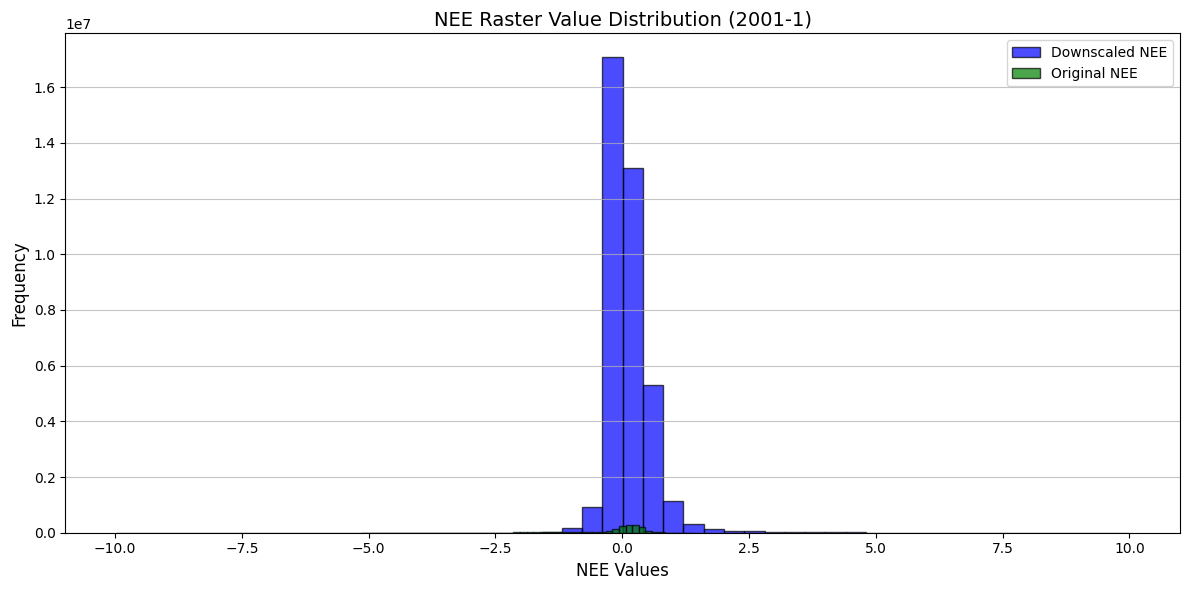

In [84]:


def plot_histogram_within_range(year_month, valid_values, bins=50, title="Raster Value Distribution"):
    """
    Plots a histogram of raster values within a specified range.

    Parameters:
        year_month(str): e.g. '200101'
        raster_file (str): Path to the raster file.
        value_range (tuple): Range of values to include in the histogram (min, max).
        bins (int): Number of bins for the histogram (default is 50).
        title (str): Title for the histogram plot.
        year (int): Year of the data.
        month (int): Month of the data.

    Returns:
        None: Displays the histogram.
    """
    
    downscaled_nee_file = f'../gis/output/downscaledNEE/downscaledNEE_US_{year_month}.tif'
    original_nee_file = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year_month[:4]}.nc'

    with rasterio.open(downscaled_nee_file) as src:
        downscaled_nee = src.read(1)  # Read the first band
        downscaled_nee = np.where(raster_data == src.nodata, np.nan, raster_data)  # Replace nodata values with NaN

    variable = 'NEE'
    ds = xr.open_dataset(original_nee_file)
    original_nee = ds[variable][int(year_month[4:]) - 1].values  # Extract data for the specified month

    min_val, max_val = value_range

    valid_downscaled = downscaled_nee[(~np.isnan(downscaled_nee)) & (downscaled_nee >= min_val) & (downscaled_nee <= max_val)]
    valid_original = original_nee[(~np.isnan(original_nee)) & (original_nee >= min_val) & (original_nee <= max_val)]

    # Plot the histograms
    plt.figure(figsize=(12, 6))
    plt.hist(valid_downscaled, bins=bins, color='blue', alpha=0.7, edgecolor='black', label='Downscaled NEE')
    plt.hist(valid_original, bins=bins, color='green', alpha=0.7, edgecolor='black', label='Original NEE')
    plt.title(title, fontsize=14)
    plt.xlabel('NEE Values', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()
    
    # # Plot the histogram
    # plt.figure(figsize=(10, 6))
    # plt.hist(valid_values, bins=bins, color='blue', alpha=0.7, edgecolor='black')
    # plt.title(title, fontsize=14)
    # plt.xlabel('Raster value', fontsize=12)
    # plt.ylabel('Pixel count', fontsize=12)
    # plt.grid(axis='y', alpha=0.75)
    # plt.tight_layout()
    # plt.show()

# year = 2001
# month = 1
year_month = '200101'
value_range = (-10, 10)  # Specify the range of values to include in the histogram
plot_histogram_within_range(year_month, valid_values, bins=50, title=f"NEE Raster Value Distribution ({str(year)}-{str(month)})")


In [85]:
max(valid_downscaled)

np.float32(54573.785)

In [86]:
# Plot the pixel percentage histograms

# raster_area_ratio = (len(downscaled_nee) * len(downscaled_nee[0])) / (len(original_nee) * len(original_nee[0]))
valid_downscaled_perc = valid_downscaled / (len(downscaled_nee) * len(downscaled_nee[0]))
# valid_original = original_nee[(~np.isnan(original_nee)) & (original_nee >= min_val) & (original_nee <= max_val)]
valid_original_perc = valid_original / (len(original_nee) * len(original_nee[0]))


plt.figure(figsize=(12, 12))
plt.hist(valid_downscaled_perc, bins=bins, color='blue', alpha=0.7, edgecolor='black', label='Downscaled NEE percentage')
plt.hist(valid_original_perc, bins=bins, color='green', alpha=0.7, edgecolor='black', label='Original NEE percentage')
plt.title(title, fontsize=14)
plt.xlabel('NEE Values', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [42]:
valid_downscaled_perc

array([3.6241408e-09, 1.8559740e-09, 0.0000000e+00, ..., 1.5029079e-09,
       1.4759499e-09, 1.3613785e-09], dtype=float32)

In [38]:
print

9331200


In [39]:
print(len(downscaled_nee) * len(downscaled_nee[0]))

206291258


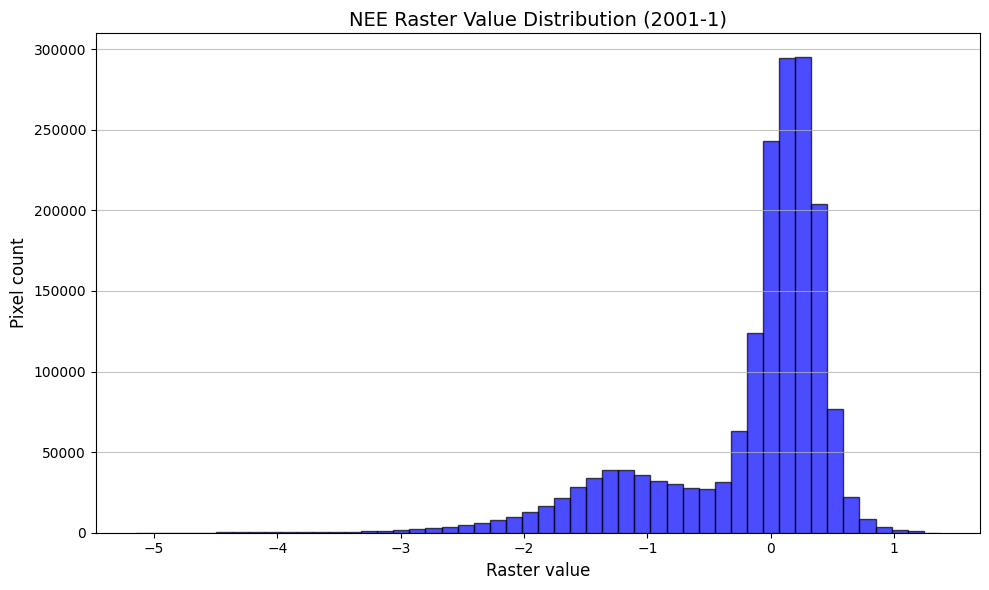

In [26]:
nee_raw_file = f"../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year}.nc"
plot_histogram_within_range(nee_raw_file, value_range, year, month, bins=50, title=f"NEE Raster Value Distribution ({str(year)}-{str(month)})")



In [ ]:


value_range = (-5, 5) 
plot_histogram_within_range(nee_raw_file, value_range, bins=50, title="NEE Raster Value Distribution (-10 to 50)")

In [ ]:
year_month = '200101'
downscaled_nee_file_path = f'../gis/output/downscaledNEE/downscaledNEE_US_{year_month}.tif'
with rasterio.open(downscaled_nee_file_path) as nee_dstrd:
    for index, record in msa_ds.iterrows():
        msa_name = record['NAMELSAD']
        # print(f'Generating downscaled data for {msa_name}...')
        msa = msa_ds.loc[[index]]

